# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [99]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.5

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [100]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

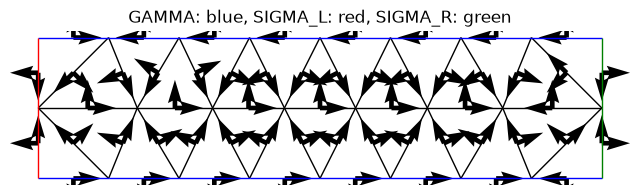

In [101]:
waveguide.plot()

In [102]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [103]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [120]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.LEFT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [121]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [122]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [123]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [124]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 13
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

390

and an assembler:

In [125]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [126]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [127]:
A = P.assemble_LHS()

Interior: 100%|██████████| 35/35 [00:01<00:00, 25.93edge/s]


assembling local operators
region: Gamma


100%|██████████| 16/16 [00:00<00:00, 200.16edge/s]


region: Sigma_L


100%|██████████| 2/2 [00:00<00:00, 212.75edge/s]


region: Sigma_R


100%|██████████| 2/2 [00:00<00:00, 218.69edge/s]


assembling non-local operators


NtD: 100%|██████████| 2/2 [00:01<00:00,  1.16edge/s]


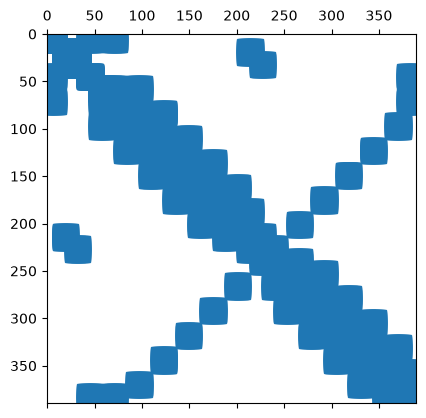

In [128]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [129]:
b = P.assemble_RHS()

In [130]:
P.solve()

In [131]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 6.33143583e-02+1.95762783e-01j,  8.41299074e-02-1.48451782e-01j,
        -2.60733962e-01-8.24378745e-02j,  6.36569252e-01-1.12304640e-01j,
        -5.61137035e-01+2.48733791e-01j,  2.59200104e-02-2.64597101e-02j,
        -3.75900120e-01+7.93235424e-02j,  3.84720943e-01+2.64301338e-01j,
         1.51486523e-02+2.83611758e-01j, -3.32787527e-01-4.25097479e-01j,
         1.37746272e-01+3.01479321e-01j, -1.08818202e-01+4.03296496e-03j,
        -3.80031815e-01-1.32192315e-01j],
       [ 2.27345711e-01-3.42624713e-01j, -3.46467689e-01-1.52900905e-01j,
         1.40364689e-01-1.54702723e-01j,  5.62092580e-02+2.33884570e-01j,
        -1.74972207e-01-4.06511771e-02j,  1.30331034e-01+1.06424330e-01j,
         2.42987711e-01-1.35765934e-01j, -4.13104873e-01+1.95887819e-01j,
        -3.80611301e-01+3.23969188e-01j,  2.03007869e-01+1.93925492e-01j,
        -3.56113567e-01-7.36538993e-03j,  4.87541121e-01+1.18954795e-01j,
        -1.96763029e-01-4.41586391e-01j],
       [ 2.24724621e-01-3.50

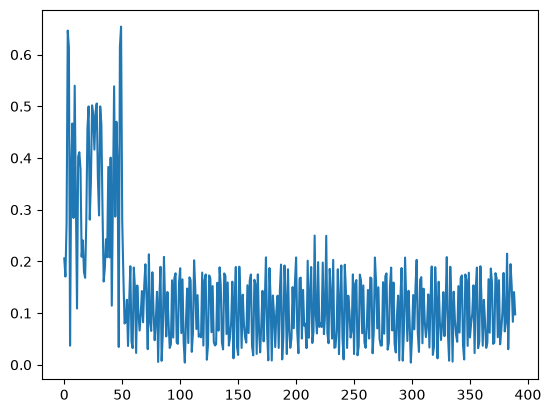

In [132]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [133]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

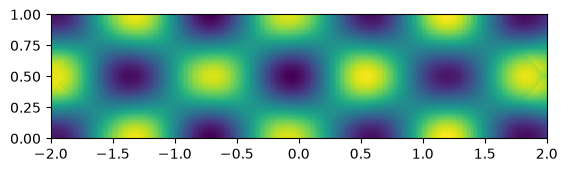

In [134]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

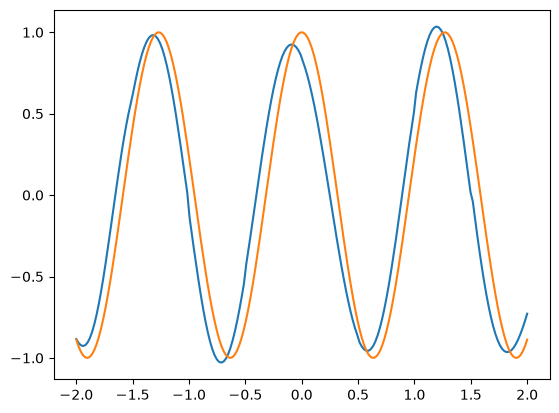

In [135]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)